In [ ]:
#Scenario
# A city is building a Smart Traffic Monitoring System to improve road safety.
# Every intersection in the city will have cameras that detect traffic signs automatically.
# The system must recognize different road signs such as:
# Stop sign
# Speed limit sign
# Pedestrian crossing sign
# The system will be used in autonomous vehicles and traffic monitoring cameras.
# However, the engineers discovered two challenges:
# First, the system must understand basic classification logic (learning from features).
# Second, it must classify images of traffic signs captured by cameras.
# To solve this, the engineering team decided to build the system in two stages.
# Stage 1
# Learning Basic Neural Networks (Perceptron)
# Before building a full image model, the engineers want students to first implement a Perceptron-based
# neural network to understand how neural networks make decisions.
# The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.
# Dataset is available in DatasetCapstoneProject4 in the github repo link https://github.com/himanshusar123/Datasets

In [13]:
# 1. Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# 2. Load Dataset
df = pd.read_csv("smart_traffic_sign_dataset.csv")
df.head()

,Sign_ID,Red_Color_Intensity,Circular_Shape,Text_Present,Edge_Count,Stop_Sign
0,1,0.90,0,1,8,1
1,2,0.20,1,0,4,0
2,3,0.85,0,1,7,1
3,4,0.30,1,0,5,0
4,5,0.88,0,1,8,1


In [15]:
# 3. Dataset Information
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sign_ID              10 non-null     int64  
 1   Red_Color_Intensity  10 non-null     float64
 2   Circular_Shape       10 non-null     int64  
 3   Text_Present         10 non-null     int64  
 4   Edge_Count           10 non-null     int64  
 5   Stop_Sign            10 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 612.0 bytes
None
        Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  \
count  10.00000            10.000000       10.000000     10.000000   
mean    5.50000             0.579000        0.500000      0.500000   
std     3.02765             0.322127        0.527046      0.527046   
min     1.00000             0.200000        0.000000      0.000000   
25%     3.25000             0.285000        0.000000      0.000000   
50%     5.50000             0.

In [16]:
# 4. Define Features and Target
X = df.drop(["Sign_ID", "Stop_Sign"], axis=1)
y = df["Stop_Sign"]

In [17]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [18]:
# 6. Create Perceptron Model
model = Perceptron()

In [19]:
# 7. Train Model
model.fit(X_train,y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [20]:
# 8. Predictions
y_pred = model.predict(X_test)

In [21]:
# 9. Model Evaluation
print(f"\nModel Accuracy:{accuracy_score(y_test, y_pred).__round__(4)*100}%")
print("\nClassification Report:\n",classification_report(y_test,y_pred))


Model Accuracy:100.0%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



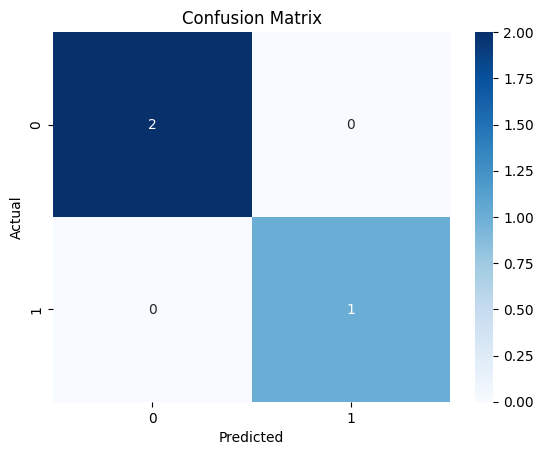

In [22]:
# 10. Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure()
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()